# 🪪 PaddleOCR v5 — Fine-tuning cho CCCD Việt Nam (144k ảnh)

> **Pipeline training**:
> ```
> 144k ảnh từ rec_gt_train.txt
>       ↓ Xáo trộn dữ liệu (tránh sắp xếp theo nhóm)
> Chia thành train (80%), val (10%), test (10%)
>       ↓ Finetuning từ PP-OCRv5 pretrained
> Model nhận diện CCCD chuẩn
> ```
> **GPU**: T4 (Google Colab Free) hoặc Local
>
> **Thời gian ước tính**:
> - T4 Colab: ~3-4 giờ (30 epoch)
> - RTX 3090: ~2 giờ

---
## 📋 Mục lục
1. Kiểm tra GPU
2. Cài đặt môi trường
3. Load & Chuẩn bị dataset từ rec_gt_train.txt
4. Xáo trộn và chia dữ liệu (80/10/10)
5. Tạo Dictionary
6. Finetuning từ PP-OCRv5 pretrained
7. Evaluate & Inference
8. Export & Lưu model


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


---
## ✅ Bước 0 — Kiểm tra GPU


In [ ]:
!nvidia-smi
import torch
print(f'CUDA available: {torch.cuda.is_available()}')
print(f'GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else "None"}')

Sun Jun  7 13:59:30 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   37C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

---
## 🔧 Bước 1 — Cài đặt môi trường

In [ ]:
!pip install paddlepaddle-gpu==3.0.0 -i https://www.paddlepaddle.org.cn/packages/stable/cu118/ -q
import paddle
print(f'PaddlePaddle: {paddle.__version__} | GPU: {paddle.is_compiled_with_cuda()}')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 GB 959.0 kB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.5/65.5 kB 3.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 875.6/875.6 kB 14.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.1/13.1 MB 15.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 699.9/699.9 MB 1.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 417.9/417.9 MB 1.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 168.4/168.4 MB 6.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.1/58.1 MB 8.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 128.2/128.2 MB 6.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.1/204.1 MB 6.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.3/135.3 MB 6.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.1/99.1 kB 9.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━

/usr/local/lib/python3.12/dist-packages/paddle/utils/cpp_extension/extension_utils.py:711: UserWarning: No ccache found. Please be aware that recompiling all source files may be required. You can download and install ccache from: https://github.com/ccache/ccache/blob/master/doc/INSTALL.md
  warnings.warn(warning_message)


PaddlePaddle: 3.0.0 | GPU: True


In [ ]:
!git clone https://github.com/PaddlePaddle/PaddleOCR.git -b main --depth=1
%cd PaddleOCR
!pip install -r requirements.txt -q
!pip install -e . -q
!pip install lmdb imgaug albumentations -q
import paddleocr
print(f'PaddleOCR: {paddleocr.__version__}')

Cloning into 'PaddleOCR'...
remote: Enumerating objects: 2664, done.
remote: Counting objects: 100% (2664/2664), done.
remote: Compressing objects: 100% (1962/1962), done.
remote: Total 2664 (delta 755), reused 2024 (delta 635), pack-reused 0 (from 0)
Receiving objects: 100% (2664/2664), 95.67 MiB | 35.83 MiB/s, done.
Resolving deltas: 100% (755/755), done.
/content/PaddleOCR
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 978.2/978.2 kB 26.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 338.3/338.3 kB 35.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 98.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.7/80.7 kB 4.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.5/43.5 kB 4.6 MB/s eta 0:00:00
     ━━━━━━━━━

---
## 📁 Bước 2 — Load & Chuẩn bị Dataset từ rec_gt_train.txt

### Cấu trúc thư mục
```
/content/ocr_dataset/
├── cccd/
│   ├── train/
│   │   ├── images/
│   │   └── rec_gt_train.txt
│   ├── val/
│   │   ├── images/
│   │   └── rec_gt_val.txt
│   └── test/
│       ├── images/
│       └── rec_gt_test.txt
└── dict_viet.txt
```


In [ ]:
import os
import sys

# Tạo cấu trúc thư mục
for d in [
    '/content/ocr_dataset/cccd/train/images',
    '/content/ocr_dataset/cccd/val/images',
    '/content/ocr_dataset/cccd/test/images',
]:
    os.makedirs(d, exist_ok=True)
print('✅ Cấu trúc thư mục đã tạo')


✅ Cấu trúc thư mục đã tạo


In [ ]:
# ==================================================
# OPTION 1: LOAD DỮ LIỆU TỪ FILE ZIP TRỰC TIẾP
# (Không cần extract - tiết kiệm dung lượng)
# ==================================================
import zipfile
import os
import io
from pathlib import Path

# ⚠️ Nếu chạy trên Colab, mount Google Drive trước
# from google.colab import drive
# drive.mount('/content/drive')

# Đường dẫn file zip
zip_file_path = '/content/drive/MyDrive/rec.zip'  # ← SỬA đường dẫn zip của bạn

# Hoặc nếu chạy local:
# zip_file_path = r'd:\path\to\your_dataset.zip'

def load_data_from_zip(zip_path, label_file_in_zip='rec/rec_gt_train.txt'):
    """
    Load nhãn dữ liệu trực tiếp từ file zip

    Args:
        zip_path: Đường dẫn đến file .zip
        label_file_in_zip: Đường dẫn file label bên trong zip
                          (ví dụ: 'rec/rec_gt_train.txt')

    Returns:
        List các dòng từ file label
    """

    print(f'📦 Mở file zip: {zip_path}\n')

    try:
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            # Liệt kê các file trong zip
            all_files = zip_ref.namelist()
            print(f'📋 Tổng file trong zip: {len(all_files)}')
            print(f'   Các file quan trọng:')

            # Tìm file label
            label_files = [f for f in all_files if 'rec_gt' in f or 'label' in f]
            for lf in label_files[:5]:  # Hiển thị 5 file đầu
                print(f'     - {lf}')

            print(f'\n📖 Đọc file label: {label_file_in_zip}')

            # Đọc file label từ trong zip
            with zip_ref.open(label_file_in_zip) as label_file:
                lines = label_file.read().decode('utf-8').splitlines(keepends=True)

            print(f'✅ Đã load {len(lines)} dòng label từ zip')
            return lines, all_files, zip_ref

    except FileNotFoundError:
        print(f'❌ Không tìm thấy file zip: {zip_path}')
        return None, None, None
    except KeyError:
        print(f'❌ Không tìm thấy file {label_file_in_zip} trong zip')
        print(f'   Hãy kiểm tra lại tên file')
        return None, None, None


all_lines, all_files_in_zip, _ = load_data_from_zip(
    zip_file_path,
     label_file_in_zip='rec/rec_gt_train.txt'  # ← SỬA tên đường dẫn trong zip nếu khác
)


📦 Mở file zip: /content/drive/MyDrive/rec.zip

📋 Tổng file trong zip: 144003
   Các file quan trọng:
     - rec/rec_gt_train.txt

📖 Đọc file label: rec/rec_gt_train.txt
✅ Đã load 144000 dòng label từ zip


In [ ]:
# ==================================================
# OPTION 2: KIỂM TRA NỘI DUNG FILE ZIP & EXTRACT NẾU CẦN
# ==================================================
import zipfile
import os

def explore_zip_contents(zip_path, show_images=True):
    """
    Khám phá nội dung file zip

    Args:
        zip_path: Đường dẫn đến file .zip
        show_images: Có hiển thị ảnh hay không
    """

    print(f'🔍 KHÁM PHÁ FILE ZIP: {zip_path}\n')

    try:
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            all_files = zip_ref.namelist()

            print(f'📊 THỐNG KÊ ZIP:')
            print(f'   - Tổng file: {len(all_files)}')

            # Đếm theo loại
            images = [f for f in all_files if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
            labels = [f for f in all_files if 'txt' in f.lower()]
            folders = [f for f in all_files if f.endswith('/')]

            print(f'   - Ảnh (jpg/png): {len(images)}')
            print(f'   - File text: {len(labels)}')
            print(f'   - Folder: {len(folders)}')

            # Hiển thị file label
            print(f'\n📝 CÁC FILE LABEL:')
            for lf in labels[:10]:
                file_size = zip_ref.getinfo(lf).file_size / 1024  # KB
                print(f'   - {lf:<50} ({file_size:.1f} KB)')

            # Hiển thị ảnh mẫu
            if show_images:
                print(f'\n🖼️  MẪU CÁC ẢNH:')
                for img in images[:5]:
                    img_size = zip_ref.getinfo(img).file_size / 1024  # KB
                    print(f'   - {img:<50} ({img_size:.1f} KB)')
                if len(images) > 5:
                    print(f'   ... và {len(images) - 5} ảnh khác')

            print()
            return all_files

    except FileNotFoundError:
        print(f'❌ Không tìm thấy file zip: {zip_path}')
        return None

# Thử khám phá zip (bỏ comment khi sử dụng)
# explore_zip_contents(zip_file_path)

def extract_zip_to_dir(zip_path, extract_to_dir, specific_folder=None):
    """
    Extract file zip đến thư mục

    Args:
        zip_path: Đường dẫn file .zip
        extract_to_dir: Thư mục đích
        specific_folder: Chỉ extract folder cụ thể (ví dụ: 'rec/train/')
    """

    print(f'📦 EXTRACT ZIP...\n')

    try:
        os.makedirs(extract_to_dir, exist_ok=True)

        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            if specific_folder:
                # Extract chỉ folder cụ thể
                members = [m for m in zip_ref.namelist() if m.startswith(specific_folder)]
                zip_ref.extractall(extract_to_dir, members=members)
                print(f'✅ Extracted {len(members)} file từ "{specific_folder}" \n   Vào: {extract_to_dir}')
            else:
                # Extract tất cả
                zip_ref.extractall(extract_to_dir)
                print(f'✅ Extracted tất cả file vào: {extract_to_dir}')

        # Liệt kê kết quả
        extracted_files = []
        for root, dirs, files in os.walk(extract_to_dir):
            extracted_files.extend(files)

        print(f'   Tổng file: {len(extracted_files)}')

    except Exception as e:
        print(f'❌ Lỗi extract: {e}')


extract_zip_to_dir(
     zip_file_path,
    extract_to_dir='/content/ocr_dataset_extracted',
     specific_folder='rec/'  # Chỉ extract folder 'rec/' nếu muốn
)


📦 EXTRACT ZIP...

✅ Extracted 144003 file từ "rec/" 
   Vào: /content/ocr_dataset_extracted
   Tổng file: 144001


In [ ]:
# ==================================================
# XÁO TRỘN VÀ CHIA DỮ LIỆU (80% train, 10% val, 10% test)
# Hỗ trợ cả dữ liệu từ zip và từ thư mục local
# ==================================================
import random
import shutil
from pathlib import Path

# ⚠️ Thiết lập seed để có thể tái tạo kết quả
SEED = 42
random.seed(SEED)

# 🔹 NẾU LOAD TỪ ZIP, SỬ DỤNG CÁCH NÀY:
all_lines = load_data_from_zip(zip_file_path, label_file_in_zip='rec/rec_gt_train.txt')[0]

# 🔹 NẾU LOAD TỪ FOLDER LOCAL, SỬ DỤNG CÁCH NÀY:
#source_dir = r'd:\path\to\your\data'  # ← SỬA thành đường dẫn thực tế
#source_label_file = os.path.join(source_dir, 'rec_gt_train.txt')

'''if not os.path.exists(source_label_file):
    print(f'❌ Không tìm thấy file: {source_label_file}')
    print('⚠️ Hãy dùng load_data_from_zip() nếu dữ liệu ở trong zip')
else:
    with open(source_label_file, 'r', encoding='utf-8') as f:
        all_lines = f.readlines()'''

# Xáo trộn dữ liệu để tránh việc ảnh được sắp xếp theo nhóm
random.shuffle(all_lines)

# Chia dữ liệu theo tỷ lệ
n_total = len(all_lines)
n_train = int(n_total * 0.8)
n_val = int(n_total * 0.1)
# n_test = n_total - n_train - n_val (phần còn lại)

train_lines = all_lines[:n_train]
val_lines = all_lines[n_train:n_train + n_val]
test_lines = all_lines[n_train + n_val:]

print(f'📊 SPLIT DỮ LIỆU:')
print(f'   Train: {len(train_lines)} ({len(train_lines)/n_total*100:.1f}%)')
print(f'   Val:   {len(val_lines)} ({len(val_lines)/n_total*100:.1f}%)')
print(f'   Test:  {len(test_lines)} ({len(test_lines)/n_total*100:.1f}%)')

# Lưu các file label cho từng tập
split_labels = {
    'train': (train_lines, '/content/ocr_dataset/cccd/train/rec_gt_train.txt'),
    'val': (val_lines, '/content/ocr_dataset/cccd/val/rec_gt_val.txt'),
    'test': (test_lines, '/content/ocr_dataset/cccd/test/rec_gt_test.txt'),
}

for split_name, (lines, label_path) in split_labels.items():
    with open(label_path, 'w', encoding='utf-8') as f:
        f.writelines(lines)
    print(f'✅ {split_name.upper()}: {label_path}')


📦 Mở file zip: /content/drive/MyDrive/rec.zip

📋 Tổng file trong zip: 144003
   Các file quan trọng:
     - rec/rec_gt_train.txt

📖 Đọc file label: rec/rec_gt_train.txt
✅ Đã load 144000 dòng label từ zip
📊 SPLIT DỮ LIỆU:
   Train: 115200 (80.0%)
   Val:   14400 (10.0%)
   Test:  14400 (10.0%)
✅ TRAIN: /content/ocr_dataset/cccd/train/rec_gt_train.txt
✅ VAL: /content/ocr_dataset/cccd/val/rec_gt_val.txt
✅ TEST: /content/ocr_dataset/cccd/test/rec_gt_test.txt


In [ ]:
# ==================================================
# CÁCH 2: EXTRACT & CHUẨN HÓA TỪ FILE ZIP
# ⚠️ SỬ DỤNG NẾU DỮ LIỆU ĐANG TRONG FILE ZIP
# ==================================================
import zipfile
import unicodedata
import shutil
from pathlib import Path
from PIL import Image
import io

def normalize_and_extract_from_zip(lines, split_name, zip_path,
                                   images_folder_in_zip='rec/train/',
                                   split_dir='/content/ocr_dataset/cccd/train'):
    """
    1. Extract ảnh từ file zip
    2. Chuẩn hóa Unicode NFC cho label
    3. Copy ảnh vào split_dir/images
    4. Cập nhật đường dẫn trong label file

    Args:
        lines: List các dòng label
        split_name: 'train', 'val', hoặc 'test'
        zip_path: Đường dẫn file .zip
        images_folder_in_zip: Folder ảnh bên trong zip (ví dụ: 'rec/train/')
        split_dir: Thư mục đích để lưu
    """

    valid_lines = []
    images_dir = os.path.join(split_dir, 'images')
    os.makedirs(images_dir, exist_ok=True)

    missing_count = 0
    extracted_count = 0

    print(f'🔓 Mở file zip: {zip_path}')

    try:
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            for line in lines:
                parts = line.strip().split('\t', 1)
                if len(parts) != 2:
                    continue

                img_rel, label = parts

                # Chuẩn hóa Unicode
                label = unicodedata.normalize('NFC', label)

                # Xây dựng đường dẫn ảnh bên trong zip
                # Ví dụ: 'rec/train/111683.jpg' hoặc chỉ '111683.jpg'
                img_in_zip = os.path.join(images_folder_in_zip, os.path.basename(img_rel))

                try:
                    # Đọc ảnh từ zip
                    img_data = zip_ref.read(img_in_zip)

                    # Lấy tên file ảnh
                    img_name = os.path.basename(img_rel)

                    # Lưu ảnh vào thư mục split
                    dest_img_path = os.path.join(images_dir, img_name)
                    with open(dest_img_path, 'wb') as f:
                        f.write(img_data)

                    # Cập nhật đường dẫn
                    valid_lines.append(f'{img_name}\t{label}\n')
                    extracted_count += 1

                except KeyError:
                    # Ảnh không tìm thấy trong zip
                    missing_count += 1
                    continue

        # Lưu label file đã chuẩn hóa
        label_path = os.path.join(split_dir, f'rec_gt_{split_name}.txt')
        with open(label_path, 'w', encoding='utf-8') as f:
            f.writelines(valid_lines)

        print(f'\n✅ {split_name.upper()}:')
        print(f'   Ảnh đã extract từ zip: {extracted_count}')
        print(f'   Ảnh thiếu: {missing_count}')
        print(f'   Label file: {label_path}\n')

        return extracted_count

    except FileNotFoundError:
        print(f'❌ Không tìm thấy file zip: {zip_path}')
        return 0
    except Exception as e:
        print(f'❌ Lỗi: {e}')
        return 0

# 🔹 UNCOMMENT VÀ SỬA NẾU DÙNG DỮ LIỆU TỪ ZIP:

print('🔄 Đang extract và chuẩn hóa ảnh từ FILE ZIP...\n')

zip_path = '/content/drive/MyDrive/rec.zip'  # ← SỬA

# Thực hiện cho từng split
for split_name, (lines, _) in split_labels.items():
    split_dir = f'/content/ocr_dataset/cccd/{split_name}'

    # ← Điều chỉnh 'rec/train/' phù hợp với cấu trúc zip của bạn
    images_folder_in_zip = 'rec/train/'

    normalize_and_extract_from_zip(
        lines,
        split_name,
        zip_path,
        images_folder_in_zip=images_folder_in_zip,
        split_dir=split_dir
    )



🔄 Đang extract và chuẩn hóa ảnh từ FILE ZIP...

🔓 Mở file zip: /content/drive/MyDrive/rec.zip

✅ TRAIN:
   Ảnh đã extract từ zip: 115200
   Ảnh thiếu: 0
   Label file: /content/ocr_dataset/cccd/train/rec_gt_train.txt

🔓 Mở file zip: /content/drive/MyDrive/rec.zip

✅ VAL:
   Ảnh đã extract từ zip: 14400
   Ảnh thiếu: 0
   Label file: /content/ocr_dataset/cccd/val/rec_gt_val.txt

🔓 Mở file zip: /content/drive/MyDrive/rec.zip

✅ TEST:
   Ảnh đã extract từ zip: 14400
   Ảnh thiếu: 0
   Label file: /content/ocr_dataset/cccd/test/rec_gt_test.txt



In [ ]:
# ==================================================
# TẠO DICTIONARY TỬ ĐỘNG TỪ CÁC LABEL FILE
# ==================================================
import unicodedata

def build_dict_from_labels(*label_files, extra_chars=''):
    """Tự động tạo dict từ tất cả ký tự có trong label files"""
    chars = set(extra_chars)

    for lf in label_files:
        if not os.path.exists(lf):
            print(f'  ⚠️  Chưa có: {lf}')
            continue

        with open(lf, encoding='utf-8') as f:
            for line in f:
                parts = line.strip().split('\t', 1)
                if len(parts) == 2:
                    # Normalize về NFC (quan trọng cho tiếng Việt)
                    label = unicodedata.normalize('NFC', parts[1])
                    chars.update(label)

    # Loại bỏ ký tự điều khiển
    chars = {c for c in chars if not unicodedata.category(c).startswith('C')}

    sorted_chars = sorted(chars)
    dict_path = '/content/ocr_dataset/dict_viet.txt'

    with open(dict_path, 'w', encoding='utf-8') as f:
        for ch in sorted_chars:
            f.write(ch + '\n')

    print(f'✅ Dictionary: {dict_path}')
    print(f'   Tổng ký tự: {len(sorted_chars)}')

    return dict_path

# Build dict từ train, val, test
dict_path = build_dict_from_labels(
    '/content/ocr_dataset/cccd/train/rec_gt_train.txt',
    '/content/ocr_dataset/cccd/val/rec_gt_val.txt',
    '/content/ocr_dataset/cccd/test/rec_gt_test.txt',
    extra_chars=' 0123456789/-.,:'  # ký tự đặc biệt CCCD
)


✅ Dictionary: /content/ocr_dataset/dict_viet.txt
   Tổng ký tự: 216


In [ ]:
# ==================================================
# TẠO DICTIONARY TỰ ĐỘNG TỪ CÁC LABEL FILE VÀO GOOGLE DRIVE
# ==================================================
import os
import unicodedata
from google.colab import drive

# 1. Mount Google Drive nếu chưa mount trước đó
if not os.path.exists('/content/drive'):
    print("📸 Đang kết nối tới Google Drive của bạn...")
    drive.mount('/content/drive')

def build_dict_from_labels(*label_files, extra_chars=' '):
    """
    Tự động tạo file dict_viet.txt chứa toàn bộ ký tự độc nhất từ các file nhãn.
    Mặc định thêm khoảng trắng ' ' vào danh sách ký tự để tránh lỗi dính chữ.
    """
    chars = set(extra_chars)

    for lf in label_files:
        if not os.path.exists(lf):
            print(f'  ⚠️  Không tìm thấy file nhãn: {lf}')
            continue

        with open(lf, 'r', encoding='utf-8') as f:
            for line in f:
                # Chỉ bỏ ký tự xuống dòng \n ở cuối, giữ lại cấu trúc tab
                line = line.replace('\n', '').replace('\r', '')
                parts = line.split('\t', 1)

                if len(parts) == 2:
                    # Chuẩn hóa về dạng NFC (Cực kỳ quan trọng để tránh lỗi font tiếng Việt rã dấu)
                    label = unicodedata.normalize('NFC', parts[1])
                    chars.update(label)

    # Loại bỏ các ký tự điều khiển hệ thống (Control characters)
    chars = {c for c in chars if not unicodedata.category(c).startswith('C')}

    # Sắp xếp các ký tự theo thứ tự bảng chữ cái công khai
    sorted_chars = sorted(list(chars))

    # Định vị thư mục đích trên Google Drive của bạn
    target_dir = '/content/drive/MyDrive/PaddleOCR/cccd_v5'

    # Tự động tạo thư mục trên Drive nếu thư mục đó chưa tồn tại
    if not os.path.exists(target_dir):
        os.makedirs(target_dir)
        print(f'  📁 Đã tự động tạo cây thư mục mới trên Drive: {target_dir}')

    dict_path = os.path.join(target_dir, 'dict_viet.txt')

    # Ghi danh sách ký tự xuống file, mỗi ký tự nằm trên một dòng riêng biệt
    with open(dict_path, 'w', encoding='utf-8') as f:
        for ch in sorted_chars:
            f.write(ch + '\n')

    print('\n==================================================')
    print(f'✅ Xuất từ điển thành công lên Google Drive!')
    print(f'📍 Đường dẫn file: {dict_path}')
    print(f'🔤 Tổng số ký tự độc nhất (Unique Chars): {len(sorted_chars)}')
    print('==================================================')

    # Hiển thị trực quan một số ký tự để check nhanh
    print(f"👀 Bản xem trước ký tự: {' '.join(sorted_chars[:20])} ...")

    return dict_path

# ==================================================
# KÍCH HOẠT QUÁ TRÌNH TẠO DICTIONARY
# ==================================================
# Bạn truyền tất cả các file nhãn (Train, Train_val, Test) vào đây để quét sạch ký tự
dict_file = build_dict_from_labels(
    '/content/ocr_dataset/cccd/train/rec_gt_train.txt',
    '/content/ocr_dataset/cccd/test/rec_gt_val.txt',
    '/content/ocr_dataset/cccd/test/rec_gt_test.txt'
)

  ⚠️  Không tìm thấy file nhãn: /content/ocr_dataset/cccd/train/rec_gt_train.txt
  ⚠️  Không tìm thấy file nhãn: /content/ocr_dataset/cccd/test/rec_gt_val.txt
  ⚠️  Không tìm thấy file nhãn: /content/ocr_dataset/cccd/test/rec_gt_test.txt

✅ Xuất từ điển thành công lên Google Drive!
📍 Đường dẫn file: /content/drive/MyDrive/PaddleOCR/cccd_v5/dict_viet.txt
🔤 Tổng số ký tự độc nhất (Unique Chars): 1
👀 Bản xem trước ký tự:   ...


In [ ]:
# ==================================================
# KIỂM TRA THỐNG KÊ DỮ LIỆU
# ==================================================
import os

print('📊 KIỂM TRA DỮ LIỆU CUỐI CÙNG:\n')

for split_name in ['train', 'val', 'test']:
    split_dir = f'/content/ocr_dataset/cccd/{split_name}'
    images_dir = os.path.join(split_dir, 'images')
    label_file = os.path.join(split_dir, f'rec_gt_{split_name}.txt')

    n_images = len(os.listdir(images_dir)) if os.path.exists(images_dir) else 0

    if os.path.exists(label_file):
        with open(label_file) as f:
            n_labels = len(f.readlines())
    else:
        n_labels = 0

    print(f'{split_name.upper()}:')
    print(f'  - Ảnh: {n_images}')
    print(f'  - Labels: {n_labels}')
    print()


📊 KIỂM TRA DỮ LIỆU CUỐI CÙNG:

TRAIN:
  - Ảnh: 115200
  - Labels: 115200

VAL:
  - Ảnh: 14400
  - Labels: 14400

TEST:
  - Ảnh: 14400
  - Labels: 14400



---
## 🎨 Bước 2.5 — Tiền Xử Lý Ảnh: Chữ Đen Nền Trắng → Nền CCCD Đúng Màu

> **Mục tiêu**: Chuyển ảnh chữ đen nền trắng sang **đúng màu nền** tương ứng với từng vùng thông tin trên CCCD  
> **Khi nào dùng**: Khi dataset gốc là ảnh chữ **nền trắng** cần transform sang domain CCCD  
> **Nếu dataset đã có nền đúng màu → BỎ QUA bước này**

### 🗺️ Bảng màu nền theo từng trường CCCD:

| Trường thông tin | Màu nền | Hex |
|---|---|---|
| Số CCCD | 🟡 Vàng | `#F5A600` |
| Họ và tên | 🟡 Vàng | `#F5A600` |
| Giới tính | 🟡 Vàng | `#F5A600` |
| Ngày sinh | 🟡 Vàng | `#F5A600` |
| Quê quán | 🟡 Vàng | `#F5A600` |
| Địa chỉ thường trú | 🟡 Vàng | `#F5A600` |
| Quốc tịch | 🔵 Xanh | `#00B0F0` |
| Ngày hết hạn | 🔵 Xanh | `#00B0F0` |

> **Pipeline**:
> ```
> Label text
>       ↓ Phân loại màu nền (vàng / xanh) theo nội dung
> Ảnh chữ đen nền trắng
>       ↓ Otsu threshold → tách mask chữ
>       ↓ Tạo nền đúng màu CCCD + Gaussian noise nhẹ
>       ↓ Alpha blend chữ lên nền
> Ảnh chữ đen trên nền CCCD đúng màu
> ```


In [ ]:
# ==================================================
# CÀI ĐẶT THƯ VIỆN CẦN THIẾT CHO TIỀN XỬ LÝ ẢNH
# ==================================================
!pip install opencv-python-headless Pillow tqdm -q

import cv2
import numpy as np
import os
import re
import unicodedata
import random
from pathlib import Path
from tqdm import tqdm
import matplotlib.pyplot as plt

print('✅ Thư viện đã sẵn sàng')


✅ Thư viện đã sẵn sàng


In [ ]:
# ==================================================
# BẢNG MÀU NỀN CCCD VIỆT NAM (BGR format)
# ==================================================

# ----------------------------------------------------------
# BẢNG MÀU
# ----------------------------------------------------------

CCCD_ALL_COLORS = [
    (234, 217, 148),  # Vàng chanh chủ đạo — màu hoa sen và họa tiết chính
    (241, 236, 216),  # Vàng ngà/Trắng kem sáng (vùng highlight, nền chuyển sắc)
    (226, 209, 133),  # Vàng mỡ gà trung bình (vùng chuyển giữa xanh và vàng)
    (202, 216, 186),  # Vàng ngả xanh lá mạ nhẹ (vùng hoa sen giao thoa với nền xanh)
    (214, 198, 122),  # Vàng tối/Shadow (vùng rìa họa tiết hoặc góc khuất ánh sáng)
    (238, 225, 165),  # Vàng trung sáng rực (vùng tia sáng bảo an xung quanh quốc huy)
    (211, 226, 238),  # Median thực tế toàn vùng nền xanh chính (#D3E2EE)
    (166, 218, 242),  # Xanh chủ đạo — màu phổ biến nhất ở vùng đậm (#A6DAF2)
    (186, 228, 248),  # Xanh sáng hơn / vùng highlight nhẹ (#BAE4F8)
    (152, 208, 236),  # Xanh tối nhẹ / vùng rìa thẻ (#98D0EC)
    (206, 238, 252),  # Xanh sáng nhất / highlight mạnh gần quét sáng (#CEEEFC)
    (142, 198, 226),  # Xanh đậm — vùng shadow / góc khuất ánh sáng (#8EC6E2)
    (176, 222, 246),  # Xanh trung tính ôn hòa (#B0DEE6)
    (194, 232, 250),  # Xanh sáng dịu pha trắng (#C2E8FA)
    (202, 216, 186)   # Vùng đặc biệt: Xanh ngả vàng mạ (Giao thoa xanh-vàng #CAD8BA)
]

print(f'✅ Bảng màu CCCD: {len(CCCD_ALL_COLORS)} biến thể (8 vàng + 8 teal)')


# --------------------------------------------------
# HÀM 1: Tách mask chữ từ nền trắng
# --------------------------------------------------
def extract_text_mask(img_gray, method='otsu'):
    """
    Tach mask vung chu tu anh grayscale nen trang.
    Args:
        img_gray: Anh grayscale (numpy array HxW)
        method  : 'otsu' hoac 'adaptive'
    Returns:
        mask (uint8): 255 = vung chu, 0 = nen
    """
    if method == 'otsu':
        _, binary = cv2.threshold(
            img_gray, 0, 255,
            cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
        )
    elif method == 'adaptive':
        binary = cv2.adaptiveThreshold(
            img_gray, 255,
            cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
            cv2.THRESH_BINARY_INV,
            blockSize=15, C=8
        )
    else:
        raise ValueError('method phai la otsu hoac adaptive')

    kernel = np.ones((2, 2), np.uint8)
    mask = cv2.morphologyEx(binary, cv2.MORPH_OPEN,  kernel)
    mask = cv2.morphologyEx(mask,   cv2.MORPH_CLOSE, kernel)
    return mask


# --------------------------------------------------
# HÀM 2: Tạo nền màu CCCD
# --------------------------------------------------
def create_cccd_background(h, w, bgr_color,
                            add_noise=True, add_gradient=False):
    """
    Tao nen mau CCCD tu BGR tuple cho truoc.
    Args:
        h, w      : Chieu cao va rong
        bgr_color : BGR tuple, vi du (166, 228, 252)
        add_noise : Them Gaussian noise (+-4) cho chan thuc
        add_gradient: Them gradient ngang nhe mo phong anh sang
    Returns:
        background (uint8 BGR HxWx3)
    """
    base = np.array(bgr_color, dtype=np.uint8)
    bg   = np.full((h, w, 3), base, dtype=np.uint8)

    if add_gradient:
        grad    = np.linspace(-12, 12, w, dtype=np.float32)
        grad_2d = np.tile(grad, (h, 1))
        bg = bg.astype(np.float32)
        bg[:, :, 0] += grad_2d * 0.4
        bg[:, :, 1] += grad_2d * 0.3
        bg[:, :, 2] += grad_2d * 0.2
        bg = np.clip(bg, 0, 255).astype(np.uint8)

    if add_noise:
        noise = np.random.normal(0, 4, (h, w, 3)).astype(np.int16)
        bg = np.clip(bg.astype(np.int16) + noise, 0, 255).astype(np.uint8)

    return bg


# --------------------------------------------------
# HÀM 3: Ghép chữ lên nền màu CCCD (hàm chính)
# --------------------------------------------------
def composite_on_cccd_bg(
    img,
    bgr_color,
    threshold_method='otsu',
    text_color=(25, 25, 25),
    add_noise=True,
    add_gradient=False,
    blur_sigma=0.0
):
    """
    Chuyen anh chu den nen trang -> nen mau CCCD.
    Args:
        img              : Anh BGR (numpy array)
        bgr_color        : BGR tuple lay tu CCCD_ALL_COLORS
        threshold_method : 'otsu' hoac 'adaptive'
        text_color       : Mau chu BGR (mac dinh gan den)
        add_noise        : Them noise Gaussian vao nen
        add_gradient     : Them gradient ngang vao nen
        blur_sigma       : Gaussian blur cuoi (0 = khong blur)
    Returns:
        result (uint8 BGR)
    """
    h, w = img.shape[:2]
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY) if img.ndim == 3 else img
    mask = extract_text_mask(gray, method=threshold_method)
    bg   = create_cccd_background(h, w, bgr_color,
                                   add_noise=add_noise,
                                   add_gradient=add_gradient)
    text_layer = np.full((h, w, 3), text_color, dtype=np.uint8)
    mask_f     = mask.astype(np.float32) / 255.0
    mask_3ch   = np.stack([mask_f, mask_f, mask_f], axis=-1)
    result = (
        text_layer.astype(np.float32) * mask_3ch
        + bg.astype(np.float32)       * (1.0 - mask_3ch)
    ).astype(np.uint8)
    if blur_sigma > 0:
        result = cv2.GaussianBlur(result, (3, 3), blur_sigma)
    return result


print('\n✅ Cac ham tien xu ly da san sang:')
print('   extract_text_mask()       — Tach mask chu tu nen trang')
print('   create_cccd_background()  — Tao nen mau CCCD tu BGR tuple')
print('   composite_on_cccd_bg()    — Ghep chu len nen mau CCCD')
print(f'\n🎨 Tong so bien the mau: {len(CCCD_ALL_COLORS)}')
for i, bgr in enumerate(CCCD_ALL_COLORS):
    b, g, r = bgr
    label = 'vang' if i < 8 else 'teal'
    print(f'   {i+1:>2}. BGR{bgr}  #{r:02X}{g:02X}{b:02X}  [{label}]')


✅ Bảng màu CCCD: 15 biến thể (8 vàng + 8 teal)

✅ Cac ham tien xu ly da san sang:
   extract_text_mask()       — Tach mask chu tu nen trang
   create_cccd_background()  — Tao nen mau CCCD tu BGR tuple
   composite_on_cccd_bg()    — Ghep chu len nen mau CCCD

🎨 Tong so bien the mau: 15
    1. BGR(234, 217, 148)  #94D9EA  [vang]
    2. BGR(241, 236, 216)  #D8ECF1  [vang]
    3. BGR(226, 209, 133)  #85D1E2  [vang]
    4. BGR(202, 216, 186)  #BAD8CA  [vang]
    5. BGR(214, 198, 122)  #7AC6D6  [vang]
    6. BGR(238, 225, 165)  #A5E1EE  [vang]
    7. BGR(211, 226, 238)  #EEE2D3  [vang]
    8. BGR(166, 218, 242)  #F2DAA6  [vang]
    9. BGR(186, 228, 248)  #F8E4BA  [teal]
   10. BGR(152, 208, 236)  #ECD098  [teal]
   11. BGR(206, 238, 252)  #FCEECE  [teal]
   12. BGR(142, 198, 226)  #E2C68E  [teal]
   13. BGR(176, 222, 246)  #F6DEB0  [teal]
   14. BGR(194, 232, 250)  #FAE8C2  [teal]
   15. BGR(202, 216, 186)  #BAD8CA  [teal]


In [ ]:
# ==================================================
# XU LY BATCH: CHIA DEU 16 MAU CHO TOAN BO ANH
# Round-robin qua CCCD_ALL_COLORS, khong phan loai label
# ==================================================

def preprocess_dataset_multicolor(
    input_images_dir,
    output_images_dir,
    label_file=None,
    threshold_method='otsu',
    add_noise=True,
    add_gradient=False,
    blur_sigma=0.0,
    overwrite=False
):
    """
    Convert toan bo thu muc anh nen trang -> nen CCCD.
    Mau nen duoc gan round-robin qua CCCD_ALL_COLORS (16 mau),
    dam bao moi bien the duoc dung so luong bang nhau.
    Khong can file label — khong phan loai theo noi dung.

    Args:
        input_images_dir : Thu muc anh goc (chu den nen trang)
        output_images_dir: Thu muc luu anh sau convert
        label_file       : Khong dung — giu lai de tuong thich cu
        threshold_method : 'otsu' (mac dinh) hoac 'adaptive'
        add_noise        : Them Gaussian noise vao nen
        add_gradient     : Them gradient ngang nhe vao nen
        blur_sigma       : Gaussian blur sau cung (0 = khong blur)
        overwrite        : True = ghi de; False = bo qua anh da co
    """
    os.makedirs(output_images_dir, exist_ok=True)

    exts = {'.jpg', '.jpeg', '.png', '.bmp'}
    img_files = sorted(
        f for f in Path(input_images_dir).iterdir()
        if f.suffix.lower() in exts
    )

    if not img_files:
        print(f'⚠️  Khong tim thay anh trong: {input_images_dir}')
        return

    n_colors = len(CCCD_ALL_COLORS)
    n_total  = len(img_files)
    # Gan mau round-robin: anh thu i -> CCCD_ALL_COLORS[i % n_colors]
    color_assignment = [
        CCCD_ALL_COLORS[i % n_colors] for i in range(n_total)
    ]

    print(f'🔄 Bat dau convert {n_total} anh...')
    print(f'   Input     : {input_images_dir}')
    print(f'   Output    : {output_images_dir}')
    print(f'   Method    : threshold={threshold_method}, '
          f'noise={add_noise}, gradient={add_gradient}, blur={blur_sigma}')
    print(f'   Mau nen   : {n_colors} bien the, moi mau ~{n_total // n_colors} anh\n')

    stats = {'converted': [0] * n_colors, 'skipped': 0, 'failed': 0}

    for idx, img_path in enumerate(tqdm(img_files, desc='Converting', unit='img')):
        out_path = Path(output_images_dir) / img_path.name

        if out_path.exists() and not overwrite:
            stats['skipped'] += 1
            continue

        img = cv2.imread(str(img_path))
        if img is None:
            stats['failed'] += 1
            continue

        bgr_color = color_assignment[idx]
        color_idx = idx % n_colors
        stats['converted'][color_idx] += 1

        try:
            result = composite_on_cccd_bg(
                img,
                bgr_color        = bgr_color,
                threshold_method = threshold_method,
                add_noise        = add_noise,
                add_gradient     = add_gradient,
                blur_sigma       = blur_sigma,
            )
            cv2.imwrite(str(out_path), result)
        except Exception:
            stats['failed'] += 1

    total_converted = sum(stats['converted'])
    print(f'\n✅ Hoan thanh! {total_converted} anh da convert.')
    print('\n   Phan bo mau nen:')
    for i, (bgr, cnt) in enumerate(zip(CCCD_ALL_COLORS, stats['converted'])):
        b, g, r = bgr
        label = 'vang' if i < 8 else 'teal'
        bar = '█' * (cnt * 20 // max(max(stats['converted']), 1))
        print(f'   {i+1:>2}. #{r:02X}{g:02X}{b:02X} [{label}] {cnt:>6} anh  {bar}')
    if stats['skipped'] > 0:
        print(f'\n   ⏭  Bo qua (da ton tai): {stats["skipped"]:>6} anh')
    if stats['failed'] > 0:
        print(f'   ✗  Loi doc/ghi anh    : {stats["failed"]:>6} anh')


# ==================================================
# THUC THI: CHAY CHO CA 3 TAP TRAIN / VAL / TEST
# ==================================================
BASE_DIR = '/content/ocr_dataset/cccd'

for split in ['train', 'val', 'test']:
    img_dir = f'{BASE_DIR}/{split}/images'

    if not os.path.exists(img_dir):
        print(f'⚠️  Chua co thu muc {split}, bo qua.\n')
        continue

    print(f'\n{"="*60}')
    print(f'  [{split.upper()}]')
    print(f'{"="*60}')

    preprocess_dataset_multicolor(
        input_images_dir  = img_dir,
        output_images_dir = img_dir,
        threshold_method  = 'otsu',
        add_noise         = True,
        add_gradient      = False,
        blur_sigma        = 0.0,
        overwrite         = True
    )



  [TRAIN]
🔄 Bat dau convert 115200 anh...
   Input     : /content/ocr_dataset/cccd/train/images
   Output    : /content/ocr_dataset/cccd/train/images
   Method    : threshold=otsu, noise=True, gradient=False, blur=0.0
   Mau nen   : 15 bien the, moi mau ~7680 anh



Converting: 100%|██████████| 115200/115200 [08:37<00:00, 222.53img/s]



✅ Hoan thanh! 115200 anh da convert.

   Phan bo mau nen:
    1. #94D9EA [vang]   7680 anh  ████████████████████
    2. #D8ECF1 [vang]   7680 anh  ████████████████████
    3. #85D1E2 [vang]   7680 anh  ████████████████████
    4. #BAD8CA [vang]   7680 anh  ████████████████████
    5. #7AC6D6 [vang]   7680 anh  ████████████████████
    6. #A5E1EE [vang]   7680 anh  ████████████████████
    7. #EEE2D3 [vang]   7680 anh  ████████████████████
    8. #F2DAA6 [vang]   7680 anh  ████████████████████
    9. #F8E4BA [teal]   7680 anh  ████████████████████
   10. #ECD098 [teal]   7680 anh  ████████████████████
   11. #FCEECE [teal]   7680 anh  ████████████████████
   12. #E2C68E [teal]   7680 anh  ████████████████████
   13. #F6DEB0 [teal]   7680 anh  ████████████████████
   14. #FAE8C2 [teal]   7680 anh  ████████████████████
   15. #BAD8CA [teal]   7680 anh  ████████████████████

  [VAL]
🔄 Bat dau convert 14400 anh...
   Input     : /content/ocr_dataset/cccd/val/images
   Output    : /content/

Converting: 100%|██████████| 14400/14400 [01:04<00:00, 224.59img/s]



✅ Hoan thanh! 14400 anh da convert.

   Phan bo mau nen:
    1. #94D9EA [vang]    960 anh  ████████████████████
    2. #D8ECF1 [vang]    960 anh  ████████████████████
    3. #85D1E2 [vang]    960 anh  ████████████████████
    4. #BAD8CA [vang]    960 anh  ████████████████████
    5. #7AC6D6 [vang]    960 anh  ████████████████████
    6. #A5E1EE [vang]    960 anh  ████████████████████
    7. #EEE2D3 [vang]    960 anh  ████████████████████
    8. #F2DAA6 [vang]    960 anh  ████████████████████
    9. #F8E4BA [teal]    960 anh  ████████████████████
   10. #ECD098 [teal]    960 anh  ████████████████████
   11. #FCEECE [teal]    960 anh  ████████████████████
   12. #E2C68E [teal]    960 anh  ████████████████████
   13. #F6DEB0 [teal]    960 anh  ████████████████████
   14. #FAE8C2 [teal]    960 anh  ████████████████████
   15. #BAD8CA [teal]    960 anh  ████████████████████

  [TEST]
🔄 Bat dau convert 14400 anh...
   Input     : /content/ocr_dataset/cccd/test/images
   Output    : /content

Converting: 100%|██████████| 14400/14400 [01:05<00:00, 220.54img/s]


✅ Hoan thanh! 14400 anh da convert.

   Phan bo mau nen:
    1. #94D9EA [vang]    960 anh  ████████████████████
    2. #D8ECF1 [vang]    960 anh  ████████████████████
    3. #85D1E2 [vang]    960 anh  ████████████████████
    4. #BAD8CA [vang]    960 anh  ████████████████████
    5. #7AC6D6 [vang]    960 anh  ████████████████████
    6. #A5E1EE [vang]    960 anh  ████████████████████
    7. #EEE2D3 [vang]    960 anh  ████████████████████
    8. #F2DAA6 [vang]    960 anh  ████████████████████
    9. #F8E4BA [teal]    960 anh  ████████████████████
   10. #ECD098 [teal]    960 anh  ████████████████████
   11. #FCEECE [teal]    960 anh  ████████████████████
   12. #E2C68E [teal]    960 anh  ████████████████████
   13. #F6DEB0 [teal]    960 anh  ████████████████████
   14. #FAE8C2 [teal]    960 anh  ████████████████████
   15. #BAD8CA [teal]    960 anh  ████████████████████



🔍 Kiem tra 16 anh mau tu: /content/ocr_dataset/cccd/train/images
   Ten file                            Hue TB     Nhom mau
   ------------------------------------------------------------
   52552.jpg                             16.8      [vang]
   48378.jpg                             18.6      [vang]
   36744.jpg                             25.0      [vang]
   30028.jpg                             26.1      [vang]
   125300.jpg                            75.5      [?]
   91039.jpg                             95.2      [teal]
   82730.jpg                             74.6      [?]
   120092.jpg                            94.8      [teal]
   24287.jpg                             94.6      [teal]
   119767.jpg                            75.0      [?]
   129387.jpg                            92.9      [teal]
   125298.jpg                            93.8      [teal]
   122077.jpg                            94.4      [teal]
   63448.jpg                             21.0      [vang]
   13154

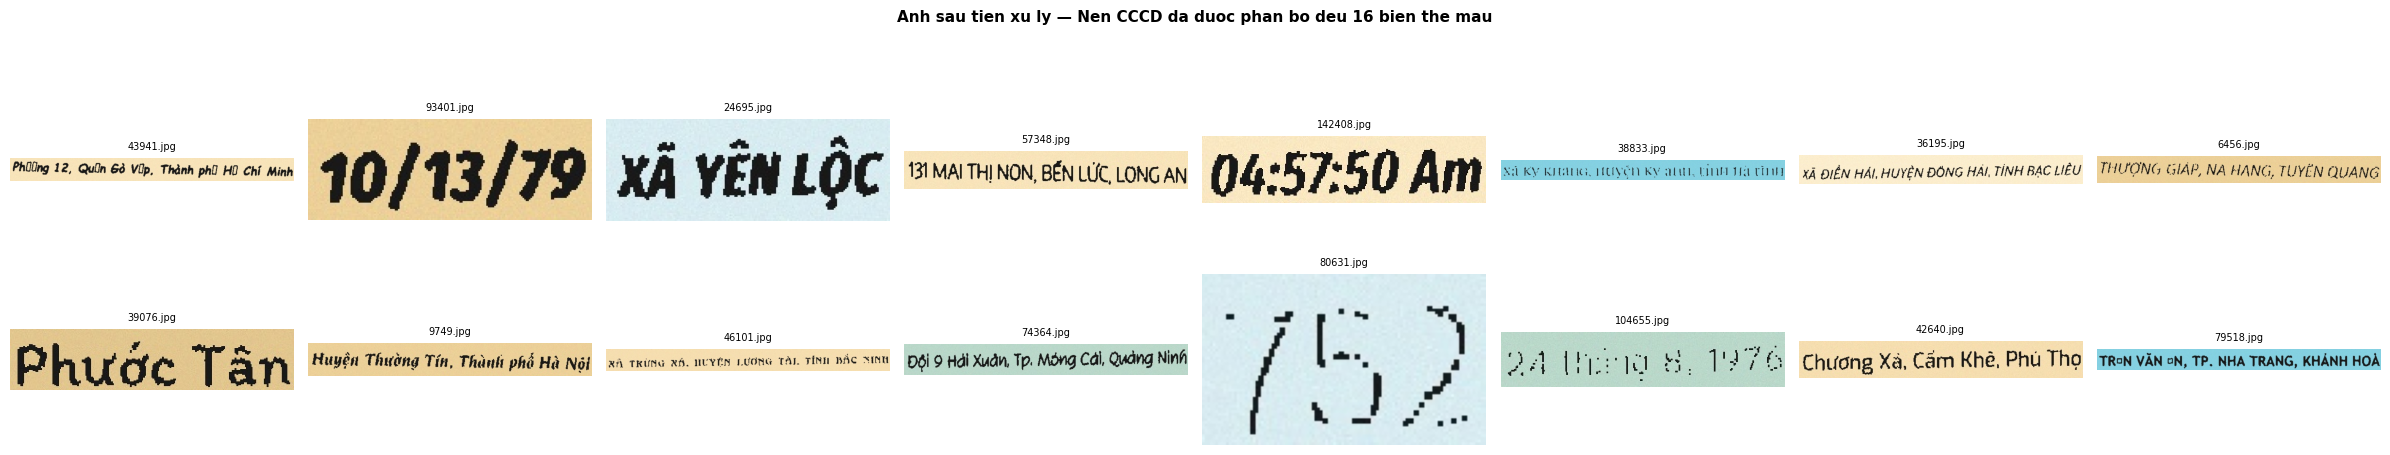

In [ ]:
# ==================================================
# KIEM TRA CHAT LUONG & HIEN THI ANH MAU
# ==================================================

def validate_color_distribution(image_dir, n_samples=16):
    """
    Kiem tra phan bo mau nen trong thu muc anh da convert.
    Do dominant hue cua moi anh va in bang thong ke.
    """
    img_files = list(Path(image_dir).glob('*.jpg')) + \
                list(Path(image_dir).glob('*.png'))
    if not img_files:
        print(f'⚠️  Khong co anh trong {image_dir}')
        return

    samples = random.sample(img_files, min(n_samples, len(img_files)))
    print(f'\n🔍 Kiem tra {len(samples)} anh mau tu: {image_dir}')
    print(f'   {"Ten file":<35} {"Hue TB":<10} {"Nhom mau"}')
    print('   ' + '-' * 60)

    hue_buckets = {'vang (15-38)': 0, 'teal (80-105)': 0, 'khac': 0}

    for img_path in samples:
        img = cv2.imread(str(img_path))
        if img is None:
            continue
        hsv  = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
        hue  = hsv[:, :, 0]
        mean_hue = float(hue.mean())

        if 15 <= mean_hue <= 38:
            group = 'vang (15-38)'
            icon  = 'vang'
        elif 80 <= mean_hue <= 105:
            group = 'teal (80-105)'
            icon  = 'teal'
        else:
            group = 'khac'
            icon  = '?'

        hue_buckets[group] += 1
        print(f'   {img_path.name:<35} {mean_hue:>6.1f}      [{icon}]')

    print(f'\n📊 Tong hop:')
    for grp, cnt in hue_buckets.items():
        print(f'   {grp:<20}: {cnt:>4} anh')


def visualize_samples(image_dir, label_file=None, n_samples=16):
    """
    Hien thi anh mau sau convert — 16 anh, moi anh 1 bien the mau.
    """
    img_files = list(Path(image_dir).glob('*.jpg')) + \
                list(Path(image_dir).glob('*.png'))
    if not img_files:
        print(f'⚠️  Khong co anh trong {image_dir}')
        return

    samples = random.sample(img_files, min(n_samples, len(img_files)))
    cols = min(8, len(samples))
    rows = (len(samples) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(3 * cols, 2.5 * rows))
    axes = np.array(axes).flatten() if rows > 1 else [axes] if cols == 1 else list(axes)

    fig.suptitle(
        'Anh sau tien xu ly — Nen CCCD da duoc phan bo deu 16 bien the mau',
        fontsize=11, fontweight='bold'
    )

    for ax, img_path in zip(axes, samples):
        img_bgr = cv2.imread(str(img_path))
        if img_bgr is None:
            continue
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        ax.imshow(img_rgb)
        ax.set_title(img_path.name[:14], fontsize=7)
        ax.axis('off')

    for ax in axes[len(samples):]:
        ax.axis('off')

    plt.tight_layout()
    plt.show()


# ==================================================
# CHAY KIEM TRA
# ==================================================
BASE_DIR = '/content/ocr_dataset/cccd'

for split in ['train', 'val', 'test']:
    img_dir = f'{BASE_DIR}/{split}/images'
    if os.path.exists(img_dir):
        validate_color_distribution(img_dir, n_samples=16)

print('\n')
train_dir = f'{BASE_DIR}/train/images'
if os.path.exists(train_dir):
    visualize_samples(train_dir, n_samples=16)


---
## 🚀 Bước 3 — Tải Pretrained Model

In [ ]:
from google.colab import files

In [ ]:
!mkdir -p /content/pretrained
%cd /content/pretrained
!wget https://paddle-model-ecology.bj.bcebos.com/paddlex/official_pretrained_model/PP-OCRv5_mobile_rec_pretrained.pdparams

/content/pretrained
--2026-06-06 07:13:25--  https://paddle-model-ecology.bj.bcebos.com/paddlex/official_pretrained_model/PP-OCRv5_mobile_rec_pretrained.pdparams
Resolving paddle-model-ecology.bj.bcebos.com (paddle-model-ecology.bj.bcebos.com)... 103.235.47.176, 2402:2b40:7000:913:0:ff:b0a4:a156
Connecting to paddle-model-ecology.bj.bcebos.com (paddle-model-ecology.bj.bcebos.com)|103.235.47.176|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 133890015 (128M) [application/octet-stream]
Saving to: ‘PP-OCRv5_mobile_rec_pretrained.pdparams’

PP-OCRv5_mobile_rec 100%[===================>] 127.69M  21.6MB/s    in 22s     

2026-06-06 07:13:48 (5.84 MB/s) - ‘PP-OCRv5_mobile_rec_pretrained.pdparams’ saved [133890015/133890015]



In [ ]:
import os
os.makedirs('/content/pretrained', exist_ok=True)

# Download file .pdparams trực tiếp — không cần tar
!wget -q --show-progress \
    https://paddle-model-ecology.bj.bcebos.com/paddlex/official_pretrained_model/PP-OCRv5_mobile_rec_pretrained.pdparams \
    -P /content/pretrained/

# Xác nhận
!ls -lh /content/pretrained/

PP-OCRv5_mobile_rec 100%[===================>] 127.69M  21.1MB/s    in 23s     
total 256M
-rw-r--r-- 1 root root 128M May 15  2025 PP-OCRv5_mobile_rec_pretrained.pdparams
-rw-r--r-- 1 root root 128M May 15  2025 PP-OCRv5_mobile_rec_pretrained.pdparams.1


---
## 🇻🇳 Bước 4 — Finetuning từ PP-OCRv5 Pretrained

> **Mục tiêu**: Fine-tune trực tiếp từ model PP-OCRv5 pretrained bằng 140k ảnh CCCD  
> **Tỷ lệ học**: 0.0005 (nhỏ để tránh overfit)  
> **Epochs**: 30-50 phụ thuộc vào bạn  
> **Thời gian**: ~6-8 giờ trên T4 (Colab)
> **Finetuning**: trong file https://drive.google.com/file/d/1OpB0TRVZnhboBV-mWN1W78KVHH-Nweei/view?usp=drive_link


In [ ]:
!python /content/PaddleOCR/tools/train.py \
-c /content/drive/MyDrive/configs/config.yml

/usr/local/lib/python3.12/dist-packages/paddle/utils/cpp_extension/extension_utils.py:711: UserWarning: No ccache found. Please be aware that recompiling all source files may be required. You can download and install ccache from: https://github.com/ccache/ccache/blob/master/doc/INSTALL.md
  warnings.warn(warning_message)
Skipping import of the encryption module.
[2026/06/06 07:24:30] ppocr INFO: Architecture : 
[2026/06/06 07:24:30] ppocr INFO:     Backbone : 
[2026/06/06 07:24:30] ppocr INFO:         name : PPLCNetV3
[2026/06/06 07:24:30] ppocr INFO:         scale : 0.95
[2026/06/06 07:24:30] ppocr INFO:     Head : 
[2026/06/06 07:24:30] ppocr INFO:         head_list : 
[2026/06/06 07:24:30] ppocr INFO:             CTCHead : 
[2026/06/06 07:24:30] ppocr INFO:                 Head : 
[2026/06/06 07:24:30] ppocr INFO:                     fc_decay : 1e-05
[2026/06/06 07:24:30] ppocr INFO:                 Neck : 
[2026/06/06 07:24:30] ppocr INFO:                     depth : 2
[2026/06/06 

In [ ]:
!python /content/PaddleOCR/tools/train.py \
-c /content/drive/MyDrive/configs/config.yml

/usr/local/lib/python3.12/dist-packages/paddle/utils/cpp_extension/extension_utils.py:711: UserWarning: No ccache found. Please be aware that recompiling all source files may be required. You can download and install ccache from: https://github.com/ccache/ccache/blob/master/doc/INSTALL.md
  warnings.warn(warning_message)
Skipping import of the encryption module.
[2026/06/06 10:07:22] ppocr INFO: Architecture : 
[2026/06/06 10:07:22] ppocr INFO:     Backbone : 
[2026/06/06 10:07:22] ppocr INFO:         name : PPLCNetV3
[2026/06/06 10:07:22] ppocr INFO:         scale : 0.95
[2026/06/06 10:07:22] ppocr INFO:     Head : 
[2026/06/06 10:07:22] ppocr INFO:         head_list : 
[2026/06/06 10:07:22] ppocr INFO:             CTCHead : 
[2026/06/06 10:07:22] ppocr INFO:                 Head : 
[2026/06/06 10:07:22] ppocr INFO:                     fc_decay : 1e-05
[2026/06/06 10:07:22] ppocr INFO:                 Neck : 
[2026/06/06 10:07:22] ppocr INFO:                     depth : 2
[2026/06/06 

In [ ]:
# 💾 LƯU MODEL VỀ DRIVE SAU KHI HOÀN THÀNH
# Bỏ comment nếu đang chạy trên Colab

import shutil

model_save_dir = '/content/drive/MyDrive/cccd_ocr_model_finetuned'
os.makedirs(model_save_dir, exist_ok=True)

# Copy best model weights
for ext in ['.pdparams', '.pdopt', '.states']:
    src = f'/content/output/cccd_finetuned/best_accuracy{ext}'
    if os.path.exists(src):
        shutil.copy2(src, model_save_dir)

# Copy config và dict
shutil.copy2('/content/configs/cccd_finetune.yml', model_save_dir)
shutil.copy2('/content/ocr_dataset/dict_viet.txt', model_save_dir)

print(f'✅ Model đã lưu: {model_save_dir}')
!ls '{model_save_dir}'


---
## 📊 Bước 5 — Evaluate trên Test Set



Finetuning - CCCD Recognition
  - Best accuracy: 0.7266
  - Final accuracy: 0.7197


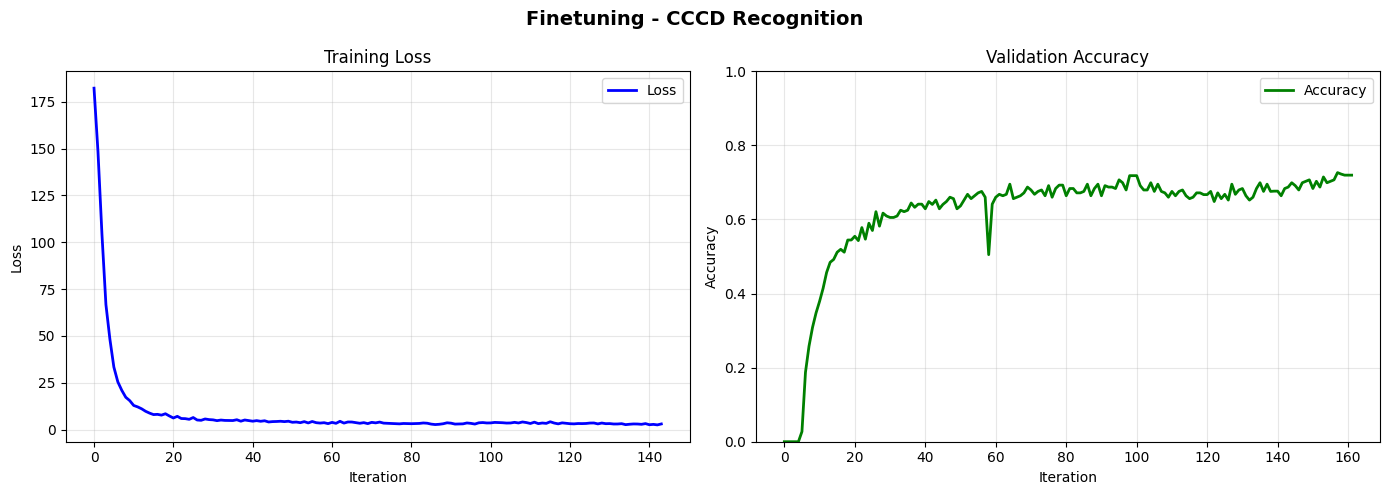

In [ ]:
# Visualize training curve
import os
import matplotlib.pyplot as plt
import re

def plot_training_log(log_file, title):
    if not os.path.exists(log_file):
        print(f'⚠️ Chưa có log: {log_file}')
        return

    losses, accs = [], []
    with open(log_file) as f:
        for line in f:
            m = re.search(r'loss: ([\d.]+)', line)
            if m:
                losses.append(float(m.group(1)))
            m2 = re.search(r'acc: ([\d.]+)', line)
            if m2:
                accs.append(float(m2.group(1)))

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(title, fontsize=14, fontweight='bold')

    if losses:
        axes[0].plot(losses, 'b-', lw=2, label='Loss')
        axes[0].set_xlabel('Iteration')
        axes[0].set_ylabel('Loss')
        axes[0].set_title('Training Loss')
        axes[0].grid(alpha=0.3)
        axes[0].legend()

    if accs:
        axes[1].plot(accs, 'g-', lw=2, label='Accuracy')
        axes[1].set_xlabel('Iteration')
        axes[1].set_ylabel('Accuracy')
        axes[1].set_title('Validation Accuracy')
        axes[1].set_ylim([0, 1])
        axes[1].grid(alpha=0.3)
        axes[1].legend()

        if accs:
            print(f'\n{title}')
            print(f'  - Best accuracy: {max(accs):.4f}')
            print(f'  - Final accuracy: {accs[-1]:.4f}')

    plt.tight_layout()
    plt.show()

# Vẽ biểu đồ nếu có log
plot_training_log('/content/drive/MyDrive/PaddleOCR/cccd_v5/train.log', 'Finetuning - CCCD Recognition')


In [ ]:
#Test
!python /content/PaddleOCR/tools/eval.py \
    -c /content/drive/MyDrive/cccd_v5/configs/eval.yml \
    -o Global.checkpoints=/content/drive/MyDrive/PaddleOCR/cccd_v5/Model/best_accuracy

/usr/local/lib/python3.12/dist-packages/paddle/utils/cpp_extension/extension_utils.py:711: UserWarning: No ccache found. Please be aware that recompiling all source files may be required. You can download and install ccache from: https://github.com/ccache/ccache/blob/master/doc/INSTALL.md
  warnings.warn(warning_message)
Skipping import of the encryption module.
[2026/06/07 14:30:43] ppocr INFO: Architecture : 
[2026/06/07 14:30:43] ppocr INFO:     Backbone : 
[2026/06/07 14:30:43] ppocr INFO:         name : PPLCNetV3
[2026/06/07 14:30:43] ppocr INFO:         scale : 0.95
[2026/06/07 14:30:43] ppocr INFO:     Head : 
[2026/06/07 14:30:43] ppocr INFO:         head_list : 
[2026/06/07 14:30:43] ppocr INFO:             CTCHead : 
[2026/06/07 14:30:43] ppocr INFO:                 Head : 
[2026/06/07 14:30:43] ppocr INFO:                     fc_decay : 1e-05
[2026/06/07 14:30:43] ppocr INFO:                 Neck : 
[2026/06/07 14:30:43] ppocr INFO:                     depth : 2
[2026/06/07 

In [ ]:
# Export model sang inference format
print('📦 Export model sang inference format...\n')

!python /content/PaddleOCR/tools/export_model.py \
    -c /content/drive/MyDrive/cccd_v5/configs/eval.yml \
    -o Global.pretrained_model=/content/drive/MyDrive/PaddleOCR/cccd_v5/Model/best_accuracy \
       Global.save_inference_dir=/content/drive/MyDrive/PaddleOCR/cccd_v5/

print('\n✅ Model exported!')
!ls /content/drive/MyDrive/PaddleOCR/cccd_v5/

📦 Export model sang inference format...

/usr/local/lib/python3.12/dist-packages/paddle/utils/cpp_extension/extension_utils.py:711: UserWarning: No ccache found. Please be aware that recompiling all source files may be required. You can download and install ccache from: https://github.com/ccache/ccache/blob/master/doc/INSTALL.md
  warnings.warn(warning_message)
Skipping import of the encryption module.
W0607 14:33:04.512185 12167 gpu_resources.cc:119] Please NOTE: device: 0, GPU Compute Capability: 7.5, Driver API Version: 13.0, Runtime API Version: 11.8
W0607 14:33:04.513499 12167 gpu_resources.cc:164] device: 0, cuDNN Version: 8.9.
[2026/06/07 14:33:05] ppocr INFO: The parameter type is float16, which is converted to float32 when loading
[2026/06/07 14:33:05] ppocr INFO: load pretrain successful from /content/drive/MyDrive/PaddleOCR/cccd_v5/Model/best_accuracy
[2026/06/07 14:33:05] ppocr INFO: Export inference config file to /content/drive/MyDrive/PaddleOCR/cccd_v5/inference.yml
Skip

In [ ]:
import os
import sys
import cv2
import numpy as np

# 1. Định vị đường dẫn mã nguồn PaddleOCR vào hệ thống để Python tìm thấy module
paddleocr_path = '/content/PaddleOCR'
if paddleocr_path not in sys.path:
    sys.path.append(paddleocr_path)

infer_path = os.path.join(paddleocr_path, 'tools/infer')
if infer_path not in sys.path:
    sys.path.append(infer_path)

# 💡 MẸO SỬA LỖI CHÍNH: Làm sạch hoàn toàn sys.argv trước khi import utility để xóa dấu vết tham số của Colab
# Ta chỉ giữ lại phần tử đầu tiên (tên file script giả lập), xóa sạch đuôi '-f /root/...json'
sys.argv = [sys.argv[0]]

# Bây giờ an tâm import module mà không sợ xung đột argument hệ thống
import tools.infer.utility as utility
from predict_rec import TextRecognizer

print('🔬 Khởi tạo lõi TextRecognizer PP-OCRv5 (Đã làm sạch sys.argv)...\n')

# Gọi hàm không truyền tham số theo đúng thiết kế của phiên bản này
args = utility.parse_args()

# 2. Ghi đè các cấu hình tùy biến của bạn cho bài toán nhận diện dòng chữ CCCD
args.use_gpu = True
args.rec_algorithm = 'MultiHead'  # Bắt buộc cho cấu trúc mạng PP-OCRv5 (CTC + NRTR)
args.rec_model_dir = '/content/drive/MyDrive/PaddleOCR/cccd_v5/'
args.rec_char_dict_path = '/content/ocr_dataset/dict_viet.txt'
args.rec_image_shape = '3, 48, 320'
args.use_space_char = True

# Khóa các nhánh không dùng tới để tối ưu tốc độ và giải phóng VRAM
args.det = False
args.rec = True
args.use_angle_cls = False

# 3. Khởi tạo bộ nhận diện ký tự
try:
    text_recognizer = TextRecognizer(args)
    print('✅ Model loaded thành công, hệ thống sẵn sàng Inference!\n')
except Exception as e:
    print(f'❌ Lỗi khởi tạo mô hình: {e}')

def recognize_cccd_text(img_path):
    """Đọc ảnh cắt dòng và trả về chuỗi ký tự cùng độ tin cậy"""
    img = cv2.imread(img_path)
    if img is None:
        return "Không đọc được file ảnh", 0.0

    try:
        # Bộ nhận diện gốc nhận đầu vào là một list các ảnh [img]
        rec_res, predict_time = text_recognizer([img])
        if rec_res and len(rec_res) > 0:
            recognized_text = rec_res[0][0]
            confidence = rec_res[0][1]
            return recognized_text, confidence
    except Exception as e:
        return f"Lỗi xử lý: {str(e)}", 0.0
    return "", 0.0

# 4. Quét và hiển thị kết quả thực tế trên 5 ảnh đầu tiên từ tập test
test_images_dir = '/content/ocr_dataset/cccd/test/images'
test_images = [f for f in os.listdir(test_images_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))][:5]

print('📸 KỲ TEST INFERENCE THỰC TẾ TRÊN 5 ẢNH:')
print('-' * 75)
for img_name in test_images:
    img_path = os.path.join(test_images_dir, img_name)
    text, conf = recognize_cccd_text(img_path)
    print(f'{img_name:<30} → {text:<30} (conf: {conf:.3f})')
print('-' * 75)

🔬 Khởi tạo lõi TextRecognizer PP-OCRv5 (Đã làm sạch sys.argv)...

[2026/06/07 14:33:13] ppocr WARNING: The first GPU is used for inference by default, GPU ID: 0
✅ Model loaded thành công, hệ thống sẵn sàng Inference!

📸 KỲ TEST INFERENCE THỰC TẾ TRÊN 5 ẢNH:
---------------------------------------------------------------------------
73877.jpg                      → Chợ Đêm Trần Phú, Trần Phú, Quận Ninh Kiều, Cần Thơ (conf: 0.974)
86518.jpg                      → 6639                           (conf: 1.000)
43613.jpg                      → Xã Ngư Thúy Nam                (conf: 0.993)
101471.jpg                     → 18 thg 7 1985                  (conf: 1.000)
121166.jpg                     → 09:10                          (conf: 0.999)
---------------------------------------------------------------------------


🔍 Đang thực hiện kiểm thử trên tập Test Set qua lõi Predictor...

  ➜ Đã xử lý xử lý thành công 1000 dòng ảnh...
  ➜ Đã xử lý xử lý thành công 2000 dòng ảnh...
  ➜ Đã xử lý xử lý thành công 3000 dòng ảnh...
  ➜ Đã xử lý xử lý thành công 4000 dòng ảnh...
  ➜ Đã xử lý xử lý thành công 5000 dòng ảnh...
  ➜ Đã xử lý xử lý thành công 6000 dòng ảnh...
  ➜ Đã xử lý xử lý thành công 7000 dòng ảnh...
  ➜ Đã xử lý xử lý thành công 8000 dòng ảnh...
  ➜ Đã xử lý xử lý thành công 9000 dòng ảnh...
  ➜ Đã xử lý xử lý thành công 10000 dòng ảnh...
  ➜ Đã xử lý xử lý thành công 11000 dòng ảnh...
  ➜ Đã xử lý xử lý thành công 12000 dòng ảnh...
  ➜ Đã xử lý xử lý thành công 13000 dòng ảnh...
  ➜ Đã xử lý xử lý thành công 14000 dòng ảnh...

✅ Đã hoàn tất dự đoán toán bộ 14400 ảnh dòng chữ.

📊 BÁO CÁO CHỈ SỐ PHÂN TÍCH HIỆU NĂNG MÔ HÌNH
ĐỘ CHÍNH XÁC (ACCURACY METRICS):
  ✓ Exact Match Accuracy (Khớp toàn chuỗi):  80.89%
  ✓ Character Accuracy (Khớp ký tự):        90.10%
  ✓ Word Level Accuracy (Khớp từ):    

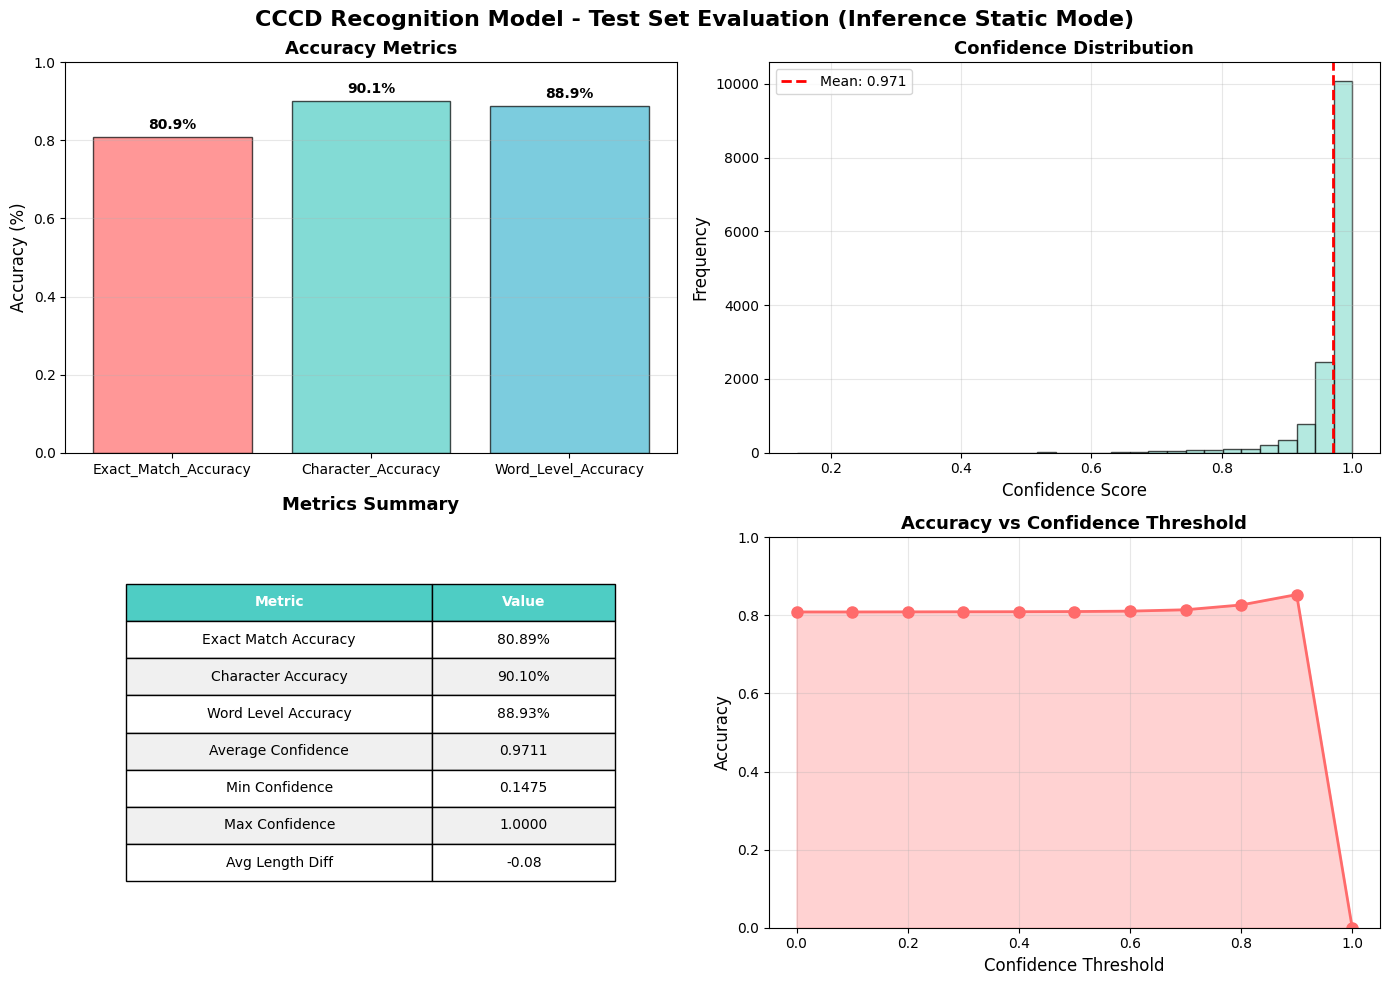


📝 HIỂN THỊ 10 MẪU THỬ THỰC TẾ (SAMPLE PREDICTIONS):

[✗ Lệch]
  🔹 Ground Truth: Z33 ĐÀO TẤN, P. PHÚ THỦY, TP. PHAN THIẾT, BÌNH THUẬN
  🔸 Predicted:    233 ĐÀO TẤN, P. PHÚ THỦY, TP. PHAN THIẾT, BÌNH THUẬN (Độ tin cậy: 0.985)

[✓ Khớp]
  🔹 Ground Truth: 4324
  🔸 Predicted:    4324 (Độ tin cậy: 0.999)

[✓ Khớp]
  🔹 Ground Truth: 18:24
  🔸 Predicted:    18:24 (Độ tin cậy: 1.000)

[✓ Khớp]
  🔹 Ground Truth: 4192
  🔸 Predicted:    4192 (Độ tin cậy: 1.000)

[✗ Lệch]
  🔹 Ground Truth: EKAREACH STREET, MITTAKPHEAP, PREAH SIHANOUK
  🔸 Predicted:    eKAreACh street, Mittakpheap, preAh sihanouk (Độ tin cậy: 0.744)

[✗ Lệch]
  🔹 Ground Truth: Chung Cu Phan Xich Long, P. 7, Quan Phu Nhuan, TP. HCM
  🔸 Predicted:    Chung Cui Phan Xich Long, P. 7, Quan Phu Nhuan, Tp. HcM (Độ tin cậy: 0.966)

[✓ Khớp]
  🔹 Ground Truth: xã vĩnh trung, huyện vĩnh linh, tỉnh quảng trị
  🔸 Predicted:    xã vĩnh trung, huyện vĩnh linh, tỉnh quảng trị (Độ tin cậy: 0.982)

[✓ Khớp]
  🔹 Ground Truth: 19:30:57
  🔸 Predicted: 

In [ ]:
# ==================================================
# TÍNH TOÁN CHỈ SỐ CHI TIẾT VÀ VẼ BIỂU ĐỒ
# ==================================================
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def calculate_ocr_metrics(gt_label_file, predictions):
    """
    Tính toán các chỉ số OCR từ tập Ground Truth và kết quả Predict
    """
    with open(gt_label_file, 'r', encoding='utf-8') as f:
        lines = f.readlines()

    gt_texts = []
    for line in lines:
        parts = line.strip().split('\t', 1)
        if len(parts) == 2:
            gt_texts.append(parts[1])

    n_samples = min(len(gt_texts), len(predictions))
    gt_texts = gt_texts[:n_samples]
    predictions = predictions[:n_samples]

    metrics = {}

    # 1. EXACT MATCH ACCURACY
    exact_matches = sum(1 for gt, (pred, _) in zip(gt_texts, predictions) if gt == pred)
    metrics['Exact_Match_Accuracy'] = exact_matches / n_samples if n_samples > 0 else 0

    # 2. CHARACTER-LEVEL ACCURACY (Sửa logic zip để tránh lỗi lệch độ dài chuỗi)
    total_chars = 0
    correct_chars = 0
    for gt, (pred, _) in zip(gt_texts, predictions):
        total_chars += len(gt)
        correct_chars += sum(1 for g, p in zip(gt, pred) if g == p)
    metrics['Character_Accuracy'] = correct_chars / total_chars if total_chars > 0 else 0

    # 3. CONFIDENCE METRICS
    confidences = [conf for _, conf in predictions]
    metrics['Average_Confidence'] = np.mean(confidences) if confidences else 0
    metrics['Min_Confidence'] = np.min(confidences) if confidences else 0
    metrics['Max_Confidence'] = np.max(confidences) if confidences else 0

    # 4. WORD-LEVEL ACCURACY
    word_matches = 0
    total_words = 0
    for gt, (pred, _) in zip(gt_texts, predictions):
        gt_words = gt.split()
        pred_words = pred.split()
        total_words += len(gt_words)
        word_matches += sum(1 for gw, pw in zip(gt_words, pred_words) if gw == pw)
    metrics['Word_Level_Accuracy'] = word_matches / total_words if total_words > 0 else 0

    # 5. LENGTH DIFFERENCE
    length_diffs = [len(pred) - len(gt) for gt, (pred, _) in zip(gt_texts, predictions)]
    metrics['Avg_Length_Difference'] = np.mean(length_diffs) if length_diffs else 0

    return metrics, gt_texts, predictions

def plot_ocr_metrics(metrics, title='Model Metrics'):
    """Vẽ hệ thống đồ thị đánh giá hiệu năng mô hình nhận diện"""
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(title, fontsize=16, fontweight='bold')

    # 1. Bar chart so sánh các tầng Accuracy
    metric_names = ['Exact_Match_Accuracy', 'Character_Accuracy', 'Word_Level_Accuracy']
    metric_values = [metrics.get(m, 0) for m in metric_names]
    colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']

    axes[0, 0].bar(metric_names, metric_values, color=colors, alpha=0.7, edgecolor='black')
    axes[0, 0].set_ylabel('Accuracy (%)', fontsize=12)
    axes[0, 0].set_title('Accuracy Metrics', fontsize=13, fontweight='bold')
    axes[0, 0].set_ylim([0, 1])
    for i, v in enumerate(metric_values):
        axes[0, 0].text(i, v + 0.02, f'{v:.1%}', ha='center', fontweight='bold')
    axes[0, 0].grid(axis='y', alpha=0.3)

    # 2. Đồ thị phân phối độ tin cậy (Confidence Distribution)
    axes[0, 1].hist(metrics.get('confidences', []), bins=30, color='#95E1D3', edgecolor='black', alpha=0.7)
    axes[0, 1].axvline(metrics.get('Average_Confidence', 0), color='red', linestyle='--', linewidth=2,
                       label=f"Mean: {metrics.get('Average_Confidence', 0):.3f}")
    axes[0, 1].set_xlabel('Confidence Score', fontsize=12)
    axes[0, 1].set_ylabel('Frequency', fontsize=12)
    axes[0, 1].set_title('Confidence Distribution', fontsize=13, fontweight='bold')
    axes[0, 1].legend()
    axes[0, 1].grid(alpha=0.3)

    # 3. Bảng tổng hợp số liệu trực quan
    axes[1, 0].axis('tight')
    axes[1, 0].axis('off')
    table_data = [
        ['Metric', 'Value'],
        ['Exact Match Accuracy', f"{metrics.get('Exact_Match_Accuracy', 0):.2%}"],
        ['Character Accuracy', f"{metrics.get('Character_Accuracy', 0):.2%}"],
        ['Word Level Accuracy', f"{metrics.get('Word_Level_Accuracy', 0):.2%}"],
        ['Average Confidence', f"{metrics.get('Average_Confidence', 0):.4f}"],
        ['Min Confidence', f"{metrics.get('Min_Confidence', 0):.4f}"],
        ['Max Confidence', f"{metrics.get('Max_Confidence', 0):.4f}"],
        ['Avg Length Diff', f"{metrics.get('Avg_Length_Difference', 0):.2f}"],
    ]
    table = axes[1, 0].table(cellText=table_data, cellLoc='center', loc='center', colWidths=[0.5, 0.3])
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1, 2)

    for i in range(2):
        table[(0, i)].set_facecolor('#4ECDC4')
        table[(0, i)].set_text_props(weight='bold', color='white')
    for i in range(1, len(table_data)):
        for j in range(2):
            table[(i, j)].set_facecolor('#F0F0F0' if i % 2 == 0 else '#FFFFFF')
    axes[1, 0].set_title('Metrics Summary', fontsize=13, fontweight='bold', pad=20)

    # 4. Mối quan hệ giữa Ngưỡng tin cậy (Confidence Threshold) và Accuracy
    confidence_levels = np.linspace(0, 1, 11)
    accuracy_by_conf = []

    if 'predictions_with_gt' in metrics:
        gt_texts, predictions = metrics['predictions_with_gt']
        for conf_threshold in confidence_levels:
            filtered = [(gt, pred) for gt, (pred, conf) in zip(gt_texts, predictions) if conf >= conf_threshold]
            if filtered:
                acc = sum(1 for gt, pred in filtered if gt == pred) / len(filtered)
                accuracy_by_conf.append(acc)
            else:
                accuracy_by_conf.append(0)

    if accuracy_by_conf:
        axes[1, 1].plot(confidence_levels, accuracy_by_conf, marker='o', linewidth=2, markersize=8, color='#FF6B6B')
        axes[1, 1].fill_between(confidence_levels, accuracy_by_conf, alpha=0.3, color='#FF6B6B')
        axes[1, 1].set_xlabel('Confidence Threshold', fontsize=12)
        axes[1, 1].set_ylabel('Accuracy', fontsize=12)
        axes[1, 1].set_title('Accuracy vs Confidence Threshold', fontsize=13, fontweight='bold')
        axes[1, 1].set_ylim([0, 1])
        axes[1, 1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

# 🔹 ĐÃ CHỈNH SỬA: KHỚP PHƯƠNG THỨC GỌI MÔ HÌNH TĨNH TRỰC TIẾP
def evaluate_on_test_set(test_label_file, test_images_dir, recognizer_model):
    """
    Evaluate mô hình sử dụng lõi TextRecognizer tĩnh
    """
    with open(test_label_file, 'r', encoding='utf-8') as f:
        lines = f.readlines()

    predictions = []
    print('🔍 Đang thực hiện kiểm thử trên tập Test Set qua lõi Predictor...\n')

    for i, line in enumerate(lines):
        parts = line.strip().split('\t', 1)
        if len(parts) != 2:
            continue

        img_name, gt_text = parts
        img_path = os.path.join(test_images_dir, img_name)

        if not os.path.exists(img_path):
            # Điền dự đoán rỗng nếu file ảnh dòng chữ bị thiếu hụt vật lý
            predictions.append(("", 0.0))
            continue

        # Đọc ảnh cắt dòng bằng OpenCV giống như cấu trúc cell trên
        img = cv2.imread(img_path)
        if img is None:
            predictions.append(("", 0.0))
            continue

        try:
            # Gọi trực tiếp bộ dự đoán của đối tượng TextRecognizer tĩnh
            rec_res, predict_time = recognizer_model([img])
            if rec_res and len(rec_res) > 0:
                pred_text = rec_res[0][0]
                confidence = rec_res[0][1]
                predictions.append((pred_text, confidence))
            else:
                predictions.append(("", 0.0))
        except Exception as e:
            predictions.append(("", 0.0))

        if (i + 1) % 1000 == 0:
            print(f'  ➜ Đã xử lý xử lý thành công {i + 1} dòng ảnh...')

    print(f'\n✅ Đã hoàn tất dự đoán toán bộ {len(predictions)} ảnh dòng chữ.\n')

    # Tính toán bộ chỉ số đầu ra
    metrics, gt_texts, preds = calculate_ocr_metrics(test_label_file, predictions)
    metrics['predictions_with_gt'] = (gt_texts, predictions)
    metrics['confidences'] = [conf for _, conf in predictions]

    return metrics, gt_texts, predictions

def print_metrics(metrics):
    """In giao diện bảng chỉ số ra màn hình"""
    print('📊 BÁO CÁO CHỈ SỐ PHÂN TÍCH HIỆU NĂNG MÔ HÌNH')
    print('=' * 60)
    print('ĐỘ CHÍNH XÁC (ACCURACY METRICS):')
    print(f'  ✓ Exact Match Accuracy (Khớp toàn chuỗi):  {metrics.get("Exact_Match_Accuracy", 0):.2%}')
    print(f'  ✓ Character Accuracy (Khớp ký tự):        {metrics.get("Character_Accuracy", 0):.2%}')
    print(f'  ✓ Word Level Accuracy (Khớp từ):          {metrics.get("Word_Level_Accuracy", 0):.2%}')
    print('\nĐỘ TIN CẬY (CONFIDENCE METRICS):')
    print(f'  ✓ Average Confidence (Độ tin cậy TB):      {metrics.get("Average_Confidence", 0):.4f}')
    print(f'  ✓ Min Confidence (Độ tin cậy thấp nhất):   {metrics.get("Min_Confidence", 0):.4f}')
    print(f'  ✓ Max Confidence (Độ tin cậy cao nhất):    {metrics.get("Max_Confidence", 0):.4f}')
    print('\nCHỈ SỐ PHỤ TRỢ:')
    print(f'  ✓ Avg Length Difference (Lệch độ dài KÝ TỰ): {metrics.get("Avg_Length_Difference", 0):+.2f}')
    print('=' * 60)


# ==================================================
# KÍCH HOẠT TIẾN TRÌNH KIỂM THỬ (EVALUATION RUN)
# ==================================================

# Gọi hàm đánh giá bằng biến mô hình `text_recognizer` đã được dựng ở cell trước
metrics, gt_texts, predictions = evaluate_on_test_set(
    '/content/ocr_dataset/cccd/test/rec_gt_test.txt',
    '/content/ocr_dataset/cccd/test/images',
    text_recognizer  # <--- Khớp đúng tên biến TextRecognizer từ cell xử lý file infer.json trước đó của bạn
)

# Xuất dữ liệu báo cáo
print_metrics(metrics)

# Vẽ hệ thống 4 biểu đồ phân tích sâu
plot_ocr_metrics(metrics, title='CCCD Recognition Model - Test Set Evaluation (Inference Static Mode)')

# Hiển thị trực quan 10 mẫu ngẫu nhiên đầu tiên để kiểm tra thực tế
print('\n📝 HIỂN THỊ 10 MẪU THỬ THỰC TẾ (SAMPLE PREDICTIONS):\n')
for i, (gt, (pred, conf)) in enumerate(zip(gt_texts[:10], predictions[:10])):
    match = "✓ Khớp" if gt == pred else "✗ Lệch"
    print(f'[{match}]')
    print(f'  🔹 Ground Truth: {gt}')
    print(f'  🔸 Predicted:    {pred} (Độ tin cậy: {conf:.3f})\n')

In [ ]:
# ==================================================
# CELL CODE MỚI: TÍNH TOÁN 3 CHỈ SỐ CER, WER, FIELD ACCURACY
# ==================================================
import numpy as np

def calculate_levenshtein_distance(s1, s2):
    """Tính khoảng cách Levenshtein giữa hai chuỗi."""
    if len(s1) < len(s2):
        return calculate_levenshtein_distance(s2, s1)

    if len(s2) == 0:
        return len(s1)

    previous_row = range(len(s2) + 1)
    for i, c1 in enumerate(s1):
        current_row = [i + 1]
        for j, c2 in enumerate(s2):
            insertions = previous_row[j + 1] + 1
            deletions = current_row[j] + 1
            substitutions = previous_row[j] + (c1 != c2)
            current_row.append(min(insertions, deletions, substitutions))
        previous_row = current_row

    return previous_row[-1]

def calculate_cer_wer_field_acc(gt_texts, predictions):
    """
    Tính toán Character Error Rate (CER), Word Error Rate (WER),
    và Field Accuracy từ tập Ground Truth và kết quả Predict.
    """
    total_chars = 0
    total_char_errors = 0
    total_words = 0
    total_word_errors = 0
    field_matches = 0
    n_samples = min(len(gt_texts), len(predictions))

    for i in range(n_samples):
        gt = gt_texts[i]
        pred = predictions[i][0] # predictions là list các tuple (pred_text, confidence)

        # 1. TÍNH CER (Character Error Rate)
        char_dist = calculate_levenshtein_distance(gt, pred)
        total_char_errors += char_dist
        total_chars += len(gt)

        # 2. TÍNH WER (Word Error Rate)
        gt_words = gt.split()
        pred_words = pred.split()
        word_dist = calculate_levenshtein_distance(gt_words, pred_words)
        total_word_errors += word_dist
        total_words += len(gt_words)

        # 3. TÍNH FIELD ACCURACY (Exact Match)
        if gt == pred:
            field_matches += 1

    # Tránh chia cho 0
    cer = total_char_errors / total_chars if total_chars > 0 else 0
    wer = total_word_errors / total_words if total_words > 0 else 0
    field_accuracy = field_matches / n_samples if n_samples > 0 else 0

    return cer, wer, field_accuracy

# --- CHẠY TÍNH TOÁN VÀ IN KẾT QUẢ ---
# (Giả sử bạn đã chạy cell code đánh giá trước đó và có biến `gt_texts` và `predictions`)

print('📊 ĐÁNH GIÁ CHỈ SỐ OCR CHI TIẾT (CHI TIẾT TRƯỜNG THÔNG TIN)')
print('=' * 60)

# Tính toán 3 chỉ số
cer, wer, field_acc = calculate_cer_wer_field_acc(gt_texts, predictions)

print(f'  ✓ Character Error Rate (CER):    {cer:.2%} (Càng thấp càng tốt)')
print(f'  ✓ Word Error Rate (WER):         {wer:.2%} (Càng thấp càng tốt)')
print(f'  ✓ Field Accuracy (Exact Match):  {field_acc:.2%} (Càng cao càng tốt)')
print('=' * 60)

📊 ĐÁNH GIÁ CHỈ SỐ OCR CHI TIẾT (CHI TIẾT TRƯỜNG THÔNG TIN)
  ✓ Character Error Rate (CER):    3.15% (Càng thấp càng tốt)
  ✓ Word Error Rate (WER):         10.05% (Càng thấp càng tốt)
  ✓ Field Accuracy (Exact Match):  80.89% (Càng cao càng tốt)


OPTIONAL

In [ ]:
# Resume finetuning nếu bị ngắt giữa quá trình
import glob

checkpoints = glob.glob('/content/output/cccd_finetuned/iter_epoch_*.pdparams')
if checkpoints:
    latest = sorted(checkpoints)[-1].replace('.pdparams', '')
    print(f'✅ Latest checkpoint: {latest}')
    print('\nBỏ comment dòng dưới để resume training:')
    print(f'!python /content/PaddleOCR/tools/train.py \\')
    print(f'    -c /content/configs/cccd_finetune.yml \\')
    print(f'    -o Global.checkpoints={latest}')
else:
    print('❌ Không tìm thấy checkpoint nào')


In [ ]:
# 💾 LƯU TẤT CẢ VỀ LOCAL HOẶC DRIVE
import shutil

# Thay đổi đường dẫn này tùy nhu cầu
model_save_dir = '/content/output/cccd_finetuned_final_save'
os.makedirs(model_save_dir, exist_ok=True)

print('💾 Lưu model...\n')

# 1. Copy inference model
print('  → Copying inference model...')
if os.path.exists('/content/output/cccd_finetuned_inference'):
    shutil.copytree(
        '/content/output/cccd_finetuned_inference',
        f'{model_save_dir}/inference',
        dirs_exist_ok=True
    )

# 2. Copy best checkpoint
print('  → Copying checkpoint weights...')
for ext in ['.pdparams', '.pdopt', '.states']:
    src = f'/content/output/cccd_finetuned/best_accuracy{ext}'
    if os.path.exists(src):
        shutil.copy2(src, f'{model_save_dir}/best_accuracy{ext}')

# 3. Copy config
print('  → Copying config and dictionary...')
shutil.copy2('/content/configs/cccd_finetune.yml', model_save_dir)
shutil.copy2('/content/ocr_dataset/dict_viet.txt', model_save_dir)

# 4. Copy training log
if os.path.exists('/content/finetune_train.log'):
    shutil.copy2('/content/finetune_train.log', model_save_dir)

print(f'\n✅ Tất cả đã lưu tại: {model_save_dir}')
print('\n📁 Nội dung thư mục:')
!ls -la '{model_save_dir}'


---
## 🛠️ Troubleshooting & Lưu ý

| Vấn đề | Giải pháp |
|--------|----------|
| `CUDA out of memory` | Giảm `batch_size_per_card`: 64→32→16 trong config |
| Accuracy không tăng | Tăng `learning_rate` từ 0.0005 lên 0.001, hoặc tăng epoch |
| Dữ liệu bị mất khi tách train/val/test | Đảm bảo xáo trộn dữ liệu (shuffle) trước khi chia |
| Ký tự OOV (out-of-vocabulary) | Thêm ký tự mới vào `dict_viet.txt` và rebuild |
| Colab bị ngắt giữa training | Sử dụng cell "Resume finetuning" để tiếp tục |
| Loss không giảm | Kiểm tra dữ liệu, có thể label sai hoặc ảnh lỗi |
| Dấu tiếng Việt bị sai | Chạy lại cell normalize_label_file để chuẩn hóa Unicode |
| Model không nhận diện tốt | Tăng epoch từ 50 lên 100, hoặc thêm data augmentation |

### 💡 Một số tham số quan trọng bạn có thể điều chỉnh:

```yaml
# Trong config CCCD finetuning:
Global:
  epoch_num: 50          # ← Tăng lên 100 nếu data ít
  max_text_length: 80    # ← Điều chỉnh theo độ dài text tối đa
  
Optimizer:
  lr:
    learning_rate: 0.0005  # ← Thử 0.001 nếu loss không giảm
    warmup_epoch: 3         # ← Giảm xuống 1 để train nhanh hơn

Train:
  loader:
    batch_size_per_card: 64  # ← Giảm xuống 32 nếu OOM
```

### ✅ Workflow khuyến nghị:

```
1. Load & Chuẩn bị dữ liệu (Load & Split)
   ↓
2. Tạo Dictionary từ dữ liệu
   ↓
3. Tải Pretrained PP-OCRv5
   ↓
4. Finetuning từ Pretrained model (~6-8h trên T4)
   ↓
5. Evaluate trên Test Set
   ↓
6. Export model sang Inference format
   ↓
7. Lưu model lên Local/Drive
```

### 📊 Kỳ vọng kết quả:

- **Val/Test Accuracy**: Nên đạt 75-85% sau 30-50 epoch (tùy dữ liệu)
- **Training time**: ~6-8 giờ trên T4 (140k ảnh, 50 epoch)
- **Model size**: ~30-40 MB (inference)


In [ ]:
# Export Stage 2 sang inference format
!python /content/PaddleOCR/tools/export_model.py \
    -c /content/configs/stage2_cccd.yml \
    -o Global.pretrained_model=/content/output/stage2_cccd/best_accuracy \
       Global.save_inference_dir=/content/output/cccd_final_inference
print('✅ Exported!')
!ls /content/output/cccd_final_inference/

In [ ]:
# Lưu tất cả về Drive
import shutil

save_dir = '/content/drive/MyDrive/cccd_ocr_model'
os.makedirs(save_dir, exist_ok=True)

# Inference model
shutil.copytree('/content/output/cccd_final_inference',
               f'{save_dir}/inference', dirs_exist_ok=True)

# Stage 2 checkpoint
for ext in ['.pdparams', '.pdopt', '.states']:
    src = f'/content/output/stage2_cccd/best_accuracy{ext}'
    if os.path.exists(src):
        shutil.copy2(src, f'{save_dir}/stage2_best_accuracy{ext}')

# Config + dict
shutil.copy2('/content/configs/stage1_wiki.yml', save_dir)
shutil.copy2('/content/configs/stage2_cccd.yml', save_dir)
shutil.copy2('/content/ocr_dataset/dict_viet.txt', save_dir)

print(f'✅ Tất cả đã lưu về: {save_dir}')
!ls '{save_dir}'

---
## 📝 Ghi chú quan trọng

### 1️⃣ **Đường dẫn dữ liệu**
- Hãy sửa dòng này trong cell "Load dữ liệu":
  ```python
  source_dir = '/path/to/archive data Kaggle final test/VietOCR-Paddle/meta/rec'
  ```
  Thay bằng đường dẫn thực tế đến thư mục chứa `rec_gt_train.txt` và thư mục `train/`

### 2️⃣ **Dữ liệu được xáo trộn trước khi chia**
- Tất cả 140k ảnh sẽ được **shuffle** (xáo trộn) trước khi chia train/val/test
- Điều này tránh việc nhóm ảnh chữ ở đầu, ảnh số ở cuối

### 3️⃣ **Tỷ lệ chia dữ liệu**
- Train: 80% (112k ảnh)
- Val: 10% (14k ảnh) — dùng để đánh giá trong quá trình training
- Test: 10% (14k ảnh) — dùng để đánh giá cuối cùng (độc lập)

### 4️⃣ **Finetuning từ Pretrained**
- Model được load từ PP-OCRv5 pretrained (tải từ internet)
- Learning rate thấp (0.0005) để tránh quên những gì đã học
- Có thể điều chỉnh epoch và learning rate tùy theo mục tiêu của bạn

### 5️⃣ **GPU Memory**
- Nếu chạy trên Colab Free (T4), batch_size=64 là hợp lý
- Nếu chạy local với GPU mạnh hơn, có thể tăng batch_size (128, 256)

**Chúc bạn thành công! 🚀**
